In [1]:
from datasets import load_from_disk

In [2]:
HF_DATASET = "/workspace-SR008.nfs2/users/barannikov/cad_refine_rl/datasets/rendered_cadevolve_normalized_1_1_deepcadf360"

hf_dataset = load_from_disk(HF_DATASET)

In [3]:
hf_dataset[1]

{'mesh_path': '/home/jovyan/shares/SR008.nfs2/users/CAD/cadexp/datasets/deepcad_fusion_train/00851900.stl',
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=476x952>,
 'prompt': '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|><|im_end|>\n<|im_start|>assistant\n'}

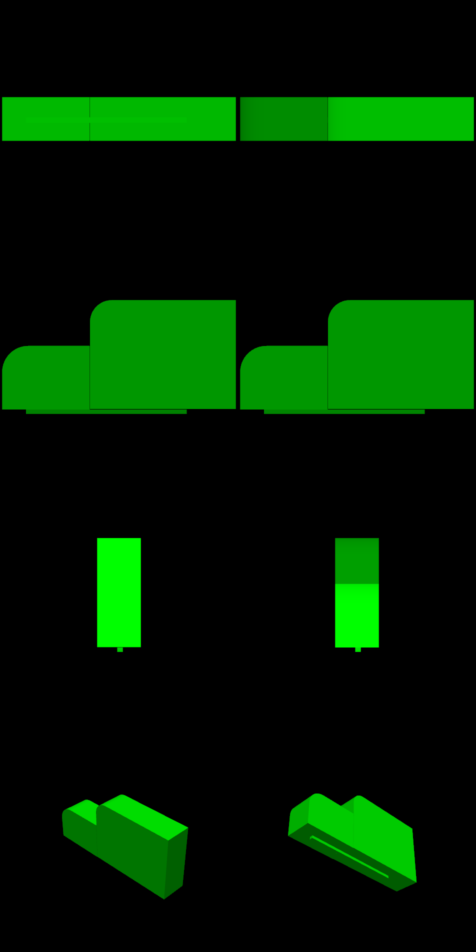

{'mesh_path': '/home/jovyan/shares/SR008.nfs2/users/CAD/cadexp/datasets/deepcad_fusion_train/00515342.stl', 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=476x952 at 0x7F28081B9B40>, 'prompt': '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|><|im_end|>\n<|im_start|>assistant\n'}


In [5]:
from IPython.display import display

index = -1678
display(hf_dataset[index]["image"])
print(hf_dataset[index])

In [4]:
import os
from pathlib import Path
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration
from torch.utils.data import ConcatDataset, DataLoader
import torch

In [5]:
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

# path to meshes
MAXPYROOT = Path(
    "/workspace-SR008.nfs2/users/zhemchuzhnikov/iterative_generation/elistratovm/monkey_patching/work_with_augmented/train_1_py"
)
MAXSTLS_ROOT = Path(
    "/workspace-SR008.nfs2/users/zhemchuzhnikov/iterative_generation/elistratovm/monkey_patching/work_with_augmented/train_1_stls"
)

DP_ROOT = Path(
    "/workspace-SR008.nfs2/users/zhemchuzhnikov/datasets/deepcad_fusion_train"
)
MCBROOT = Path("/workspace-SR008.nfs2/users/zhemchuzhnikov/datasets/MCB_A/")

# we need to load the model to get the config VISION_PATCH padding value
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, attn_implementation="flash_attention_2"
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    # min_pixels=256*28*28,
    # max_pixels=1280*28*28,
    resized_width=14 * 17 * 2,
    resized_height=14 * 17 * 4,
    padding_side="left",
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [58]:
from multiview_dataset import STLImageToCode
from vis_for_norm_parts import Plotter
from helper_visu import Plotter1_1

In [68]:
DATAROOT = Path(
    "/workspace-SR008.nfs2/users/zhemchuzhnikov/vsevolod/datasets/fusion360_test_mesh"
)
# DATAROOT = Path("/workspace-SR008.nfs2/users/zhemchuzhnikov/datasets/MCB_A_batch/groudtruth")


data = STLImageToCode(DATAROOT, split="val", size=16, shuffle=False)

getting directly from root


 94%|█████████▍| 15/16 [00:00<00:00, 6934.26it/s]


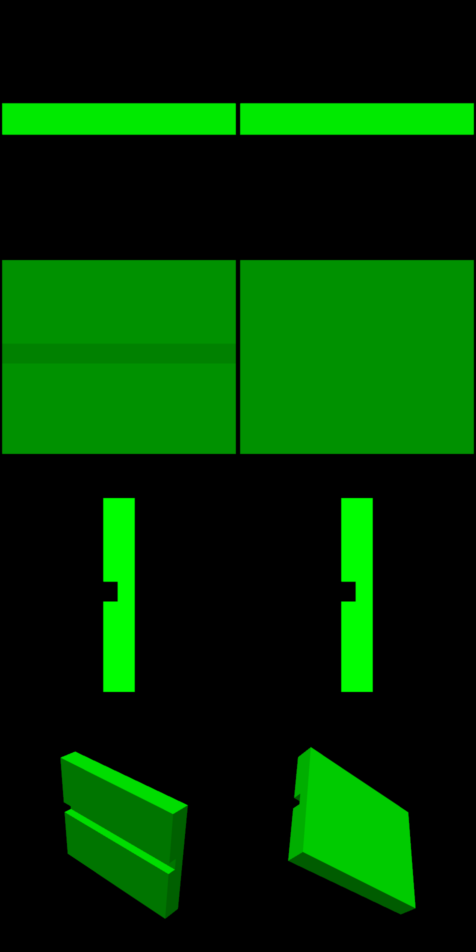

In [69]:
from IPython.display import display

display(data[13]["image"])

In [70]:
data.plotter = Plotter1_1()

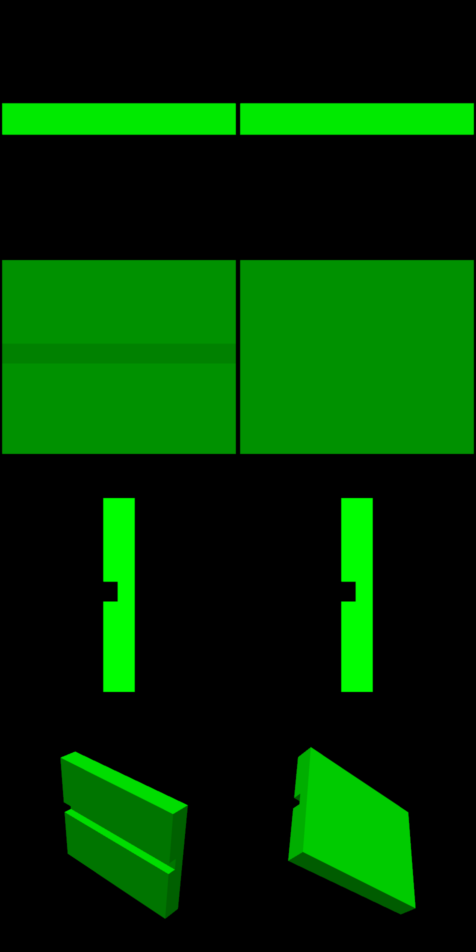

In [71]:
display(data[13]["image"])

In [1]:
from vllm.device_allocator.cumem import CuMemAllocator

INFO 11-06 13:14:42 [__init__.py:241] Automatically detected platform cuda.
